In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
import plotly.express as px
import plotly.graph_objects as go
import nbformat

from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib_venn import venn2
import os
from scipy.stats import mannwhitneyu

In [2]:
cell_types=["Tcells","Bcells",	"Fibroblasts", "NKcells", "Macrophages","Mast cells", "DCs", "other", "Endothelial cells"]
target_CAFs=["FAP", "PDGFRA", "PDGFRB", "S100A4", "LRRC15", "IL1R1", "IL1R2","SMO"]
target_receptors_molecules=["TGFB1","TGFB2","TGFB3", "TGFBR1","TGFBR2","TGFBR3","IL6", "IL6R", "IL10RA","IL10RB", "CXCL8", "CXCL12", 
 "CCR5", "CXCR2", "CXCR1", "CXCR4", "CXCL10","CXCL9","HGF", "MET", "FGF1","FGF2","FGF7","FGF10", "FGFR1","FGFR2","FGFR3","FGFR4","IL11","HAS1","HAS2","HYAL1","HYAL2"]
fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/fibroblasts_gene_expression_data_new_batch_merged_with_metadata.csv")
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/9_eyemt_patient_clinical_data_new.csv")
fibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r'(S\d+)')
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b12"]],on="Patient", how="left")
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","OS_quartile_b12"]],on="Patient", how="left")
fibr_gene_expression_modified=fibr_gene_expression_modified.drop_duplicates().reset_index(drop=True)
print(len(fibr_gene_expression_modified))
df_cell_abundance = pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_bp_res_mid_lvl_ct_ct_fraction.csv")
fibr_gene_expression_cell_abundance=fibr_gene_expression_modified.merge(df_cell_abundance, on="dcc_filename", how="left")
fibr_gene_expression_cell_abundance

444


,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,Endothelial cells,Roi_y,Segment_y,Sample_y,NACT_status_y,Annotation_cell_y,Roi.1,Segment_geomx,Patient_y,Site_y
0,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,0.028128,1.0,stroma,S130_iOme,post,CD8_Iba1,NaN,tsi,S130,Omentum
1,DSP-1001660016604-A-A03.dcc,1.260101,1.487834,1.372068,0.897518,1.051446,1.981081,4.439861,1.858659,-0.088057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DSP-1001660016604-A-A04.dcc,1.224783,1.724003,1.333149,1.528053,-0.045955,1.932914,5.415247,1.805880,-0.088144,...,0.029949,2.0,stroma,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum
3,DSP-1001660016604-A-A05.dcc,1.032495,1.168011,1.440325,0.954786,-0.044855,1.752843,5.293798,1.926242,-0.088061,...,0.029244,2.0,tumor,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum
4,DSP-1001660016604-A-A06.dcc,0.885513,1.403719,0.997214,1.190924,-0.044885,2.324255,5.864764,1.482811,-0.088064,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,DSP-1001660037247-C-D01.dcc,1.437959,1.440393,1.436729,1.241617,-0.193169,1.637498,3.101474,1.641694,-0.090027,...,0.042210,17.0,stroma,S333_pOme,pre,CD4_CD8_Iba1,NaN,stroma,S333,Omentum
440,DSP-1001660037247-C-D02.dcc,0.945847,1.243403,0.944546,0.748442,0.529108,1.884311,5.777772,1.685343,-0.090014,...,0.016802,18.0,stroma,S333_pOme,pre,CD8_CD11_Iba1,NaN,tsi,S333,Omentum
441,DSP-1001660037247-C-D03.dcc,-0.115866,0.009407,-0.109719,-0.209418,-0.136728,0.308744,7.235237,0.261484,-0.091188,...,0.010118,18.0,tumor,S333_pOme,pre,CD8_CD11_Iba1,NaN,tsi,S333,Omentum
442,DSP-1001660037247-C-D04.dcc,0.912336,1.440847,0.911072,-0.369284,-0.193441,1.110790,4.140232,1.641895,-0.090021,...,0.012752,19.0,stroma,S333_pOme,pre,CD8_CD11_Iba1,NaN,tsi,S333,Omentum


In [3]:
fibr_gene_expression_cell_abundance["PFS_HL_group"] = fibr_gene_expression_cell_abundance["PFS_quartile_b12"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)
fibr_gene_expression_cell_abundance["OS_HL_group"] = fibr_gene_expression_cell_abundance["OS_quartile_b12"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)

In [4]:
# Extract sample metadata
sample_metadata = fibr_gene_expression_cell_abundance[["Sample_y", "PFS_HL_group", "OS_HL_group"]].drop_duplicates().set_index("Sample_y")

# Properly filter for stroma + Segment_geomx == 'tsi'
stroma_cell_abundance = fibr_gene_expression_cell_abundance[
    (fibr_gene_expression_modified['Segment'] == 'stroma') & 
    (fibr_gene_expression_cell_abundance['Segment_geomx'] == 'stroma')
]

# Seems to be the same filter as above — do you really need both?
stroma_tsi_cell_abundance = fibr_gene_expression_cell_abundance[
    (fibr_gene_expression_modified['Segment'] == 'stroma') & 
    (fibr_gene_expression_cell_abundance['Segment_geomx'] == 'tsi')
]

# Group by Sample_y and compute mean abundance
average_stroma_cell_abundance_stroma = stroma_cell_abundance.groupby('Sample_y')[cell_types].mean()
average_stroma_cell_abundance_tsi = stroma_tsi_cell_abundance.groupby('Sample_y')[cell_types].mean()

# Join with metadata
stroma = average_stroma_cell_abundance_stroma.join(sample_metadata, how="inner")
tsi = average_stroma_cell_abundance_tsi.join(sample_metadata, how="inner")


In [5]:
stroma["Segment"] = "Stroma"
tsi["Segment"] = "TSI"

# Step 3: Combine both DataFrames
combined = pd.concat([stroma, tsi])

In [6]:
combined.reset_index(inplace=True)

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/1311968348.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="PFS_HL_group", y=cell, data=tsi, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/1311968348.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="PFS_HL_group", y=cell, data=tsi, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/1311968348.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(

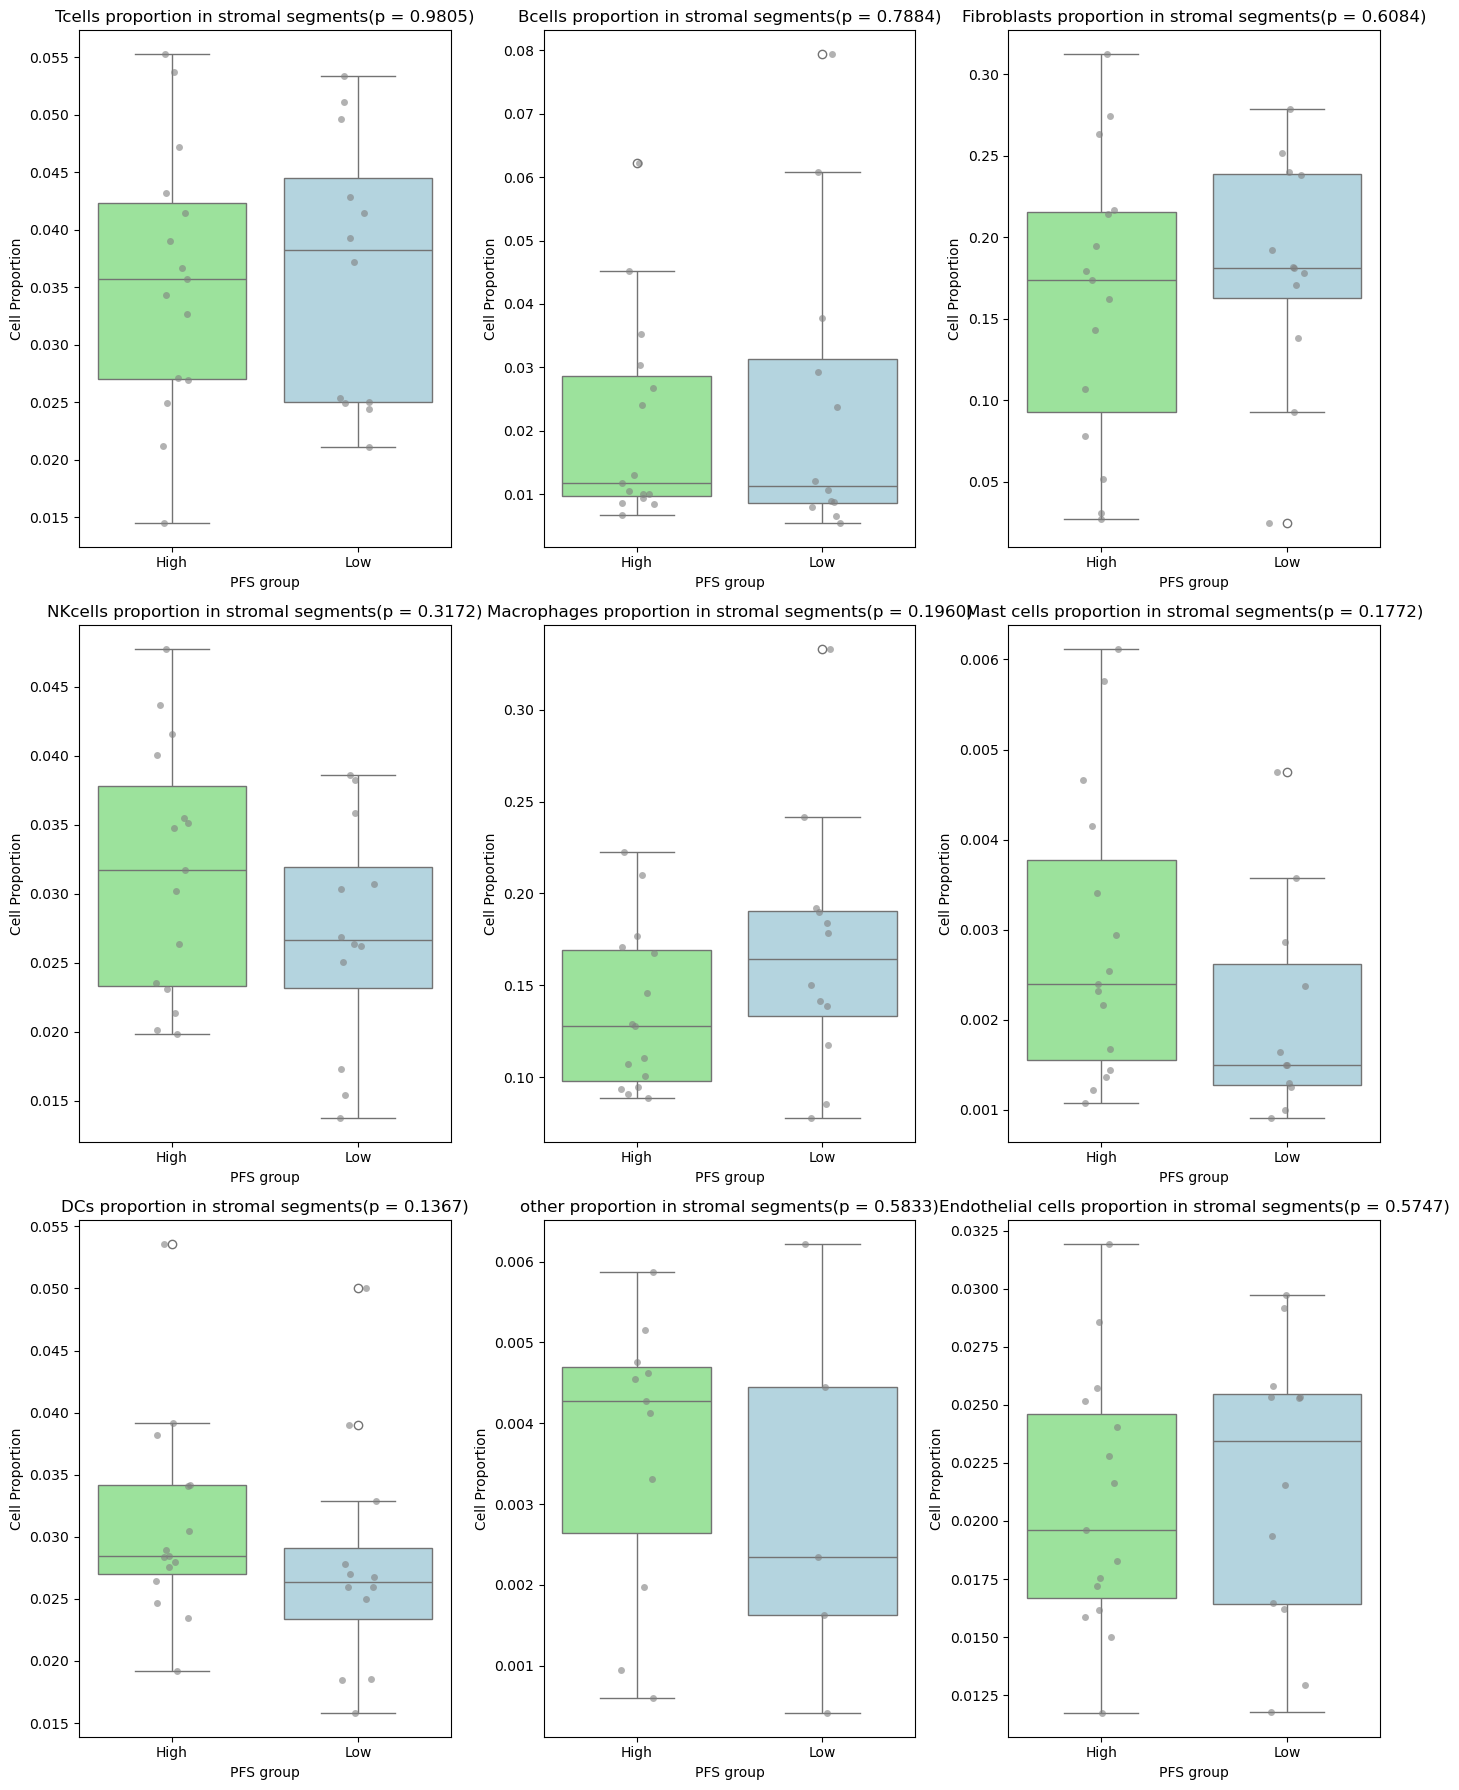

In [12]:
import math

num_plots = len(cell_types)
ncols = 3
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 6))
axes = axes.flatten()

for i, cell in enumerate(cell_types):
    combined = combined.reset_index(drop=True)
    ax = axes[i]

    # Extract data
    group_high = tsi[tsi["PFS_HL_group"] == "High"][cell]
    group_low = tsi[tsi["PFS_HL_group"] == "Low"][cell]
    group_high=group_high.dropna()
    group_low=group_low.dropna()

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_low, group_high, alternative='two-sided')

    # Plot
    sns.boxplot(x="PFS_HL_group", y=cell, data=tsi, ax=ax, palette=["lightgreen", "lightblue"])
    sns.stripplot(x="PFS_HL_group", y=cell, data=tsi, color='gray', alpha=0.6, jitter=True, ax=ax)

    # Label
    ax.set_title(f"{cell} proportion in stromal segments(p = {p_value:.4f})")
    ax.set_xlabel("PFS group")
    ax.set_ylabel("Cell Proportion")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
stroma_tsi_cell_abundance.head(3)

,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,Segment_y,Sample_y,NACT_status_y,Annotation_cell_y,Roi.1,Segment_geomx,Patient_y,Site_y,PFS_HL_group,OS_HL_group
0,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,stroma,S130_iOme,post,CD8_Iba1,NaN,tsi,S130,Omentum,Low,Low
2,DSP-1001660016604-A-A04.dcc,1.224783,1.724003,1.333149,1.528053,-0.045955,1.932914,5.415247,1.805880,-0.088144,...,stroma,S130_iOme,post,CD8_CD11_Iba1,NaN,tsi,S130,Omentum,Low,Low
6,DSP-1001660016604-A-A08.dcc,1.452303,1.272854,0.866100,1.059784,-0.044865,1.474579,3.203162,1.351901,-0.088062,...,stroma,S130_iOme,post,CD4_CD11,NaN,tsi,S130,Omentum,Low,Low


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/4018622776.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="PFS_HL_group", y=cell, data=stroma_tsi_cell_abundance, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/4018622776.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="PFS_HL_group", y=cell, data=stroma_tsi_cell_abundance, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/4018622776.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend

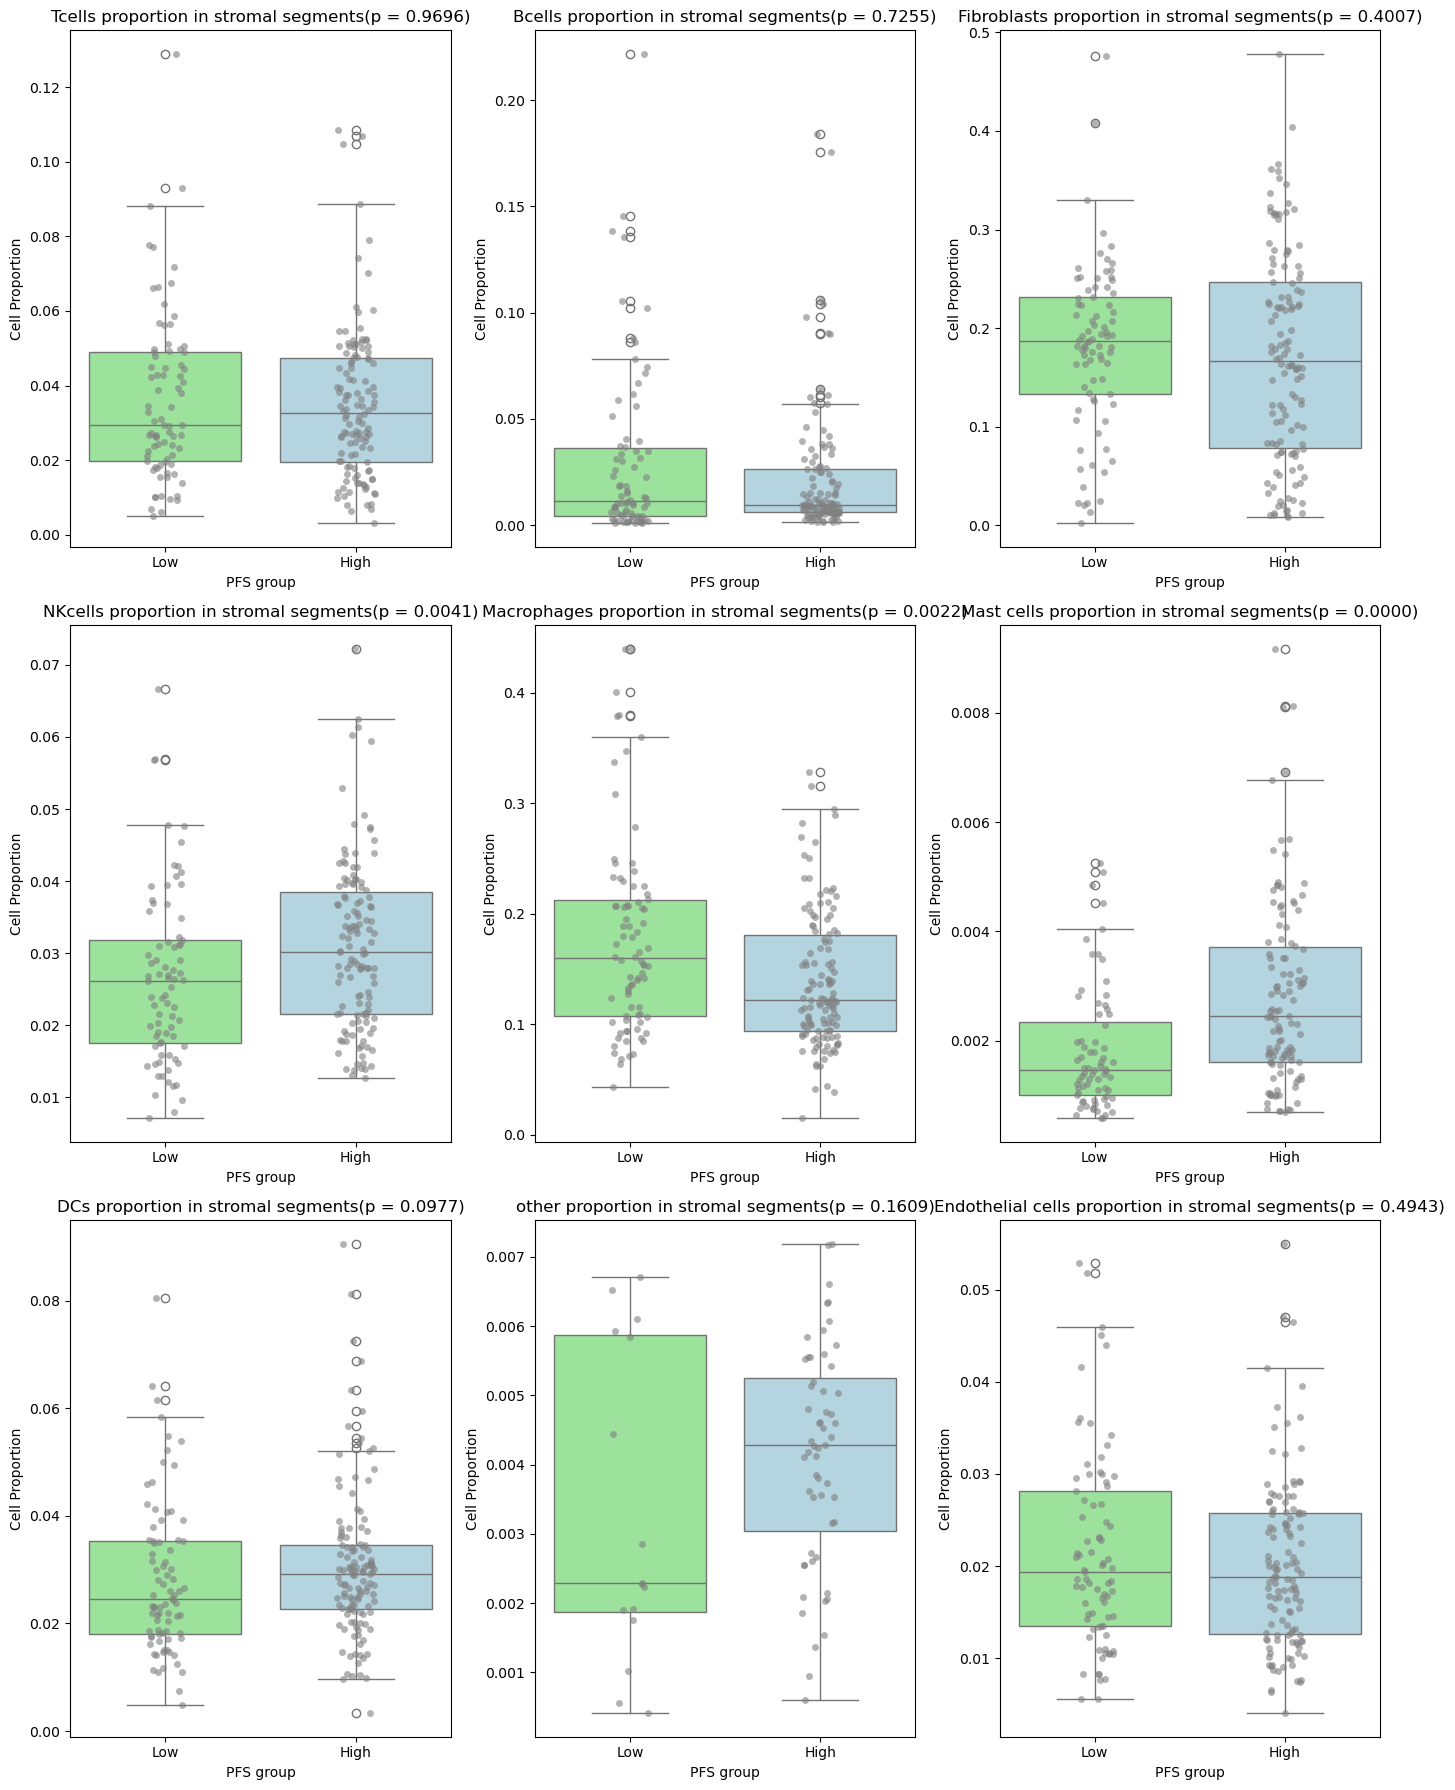

In [10]:
import math

num_plots = len(cell_types)
ncols = 3
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 6))
axes = axes.flatten()

for i, cell in enumerate(cell_types):
    combined = combined.reset_index(drop=True)
    ax = axes[i]

    # Extract data
    group_high = stroma_tsi_cell_abundance[stroma_tsi_cell_abundance["PFS_HL_group"] == "High"][cell]
    group_low = stroma_tsi_cell_abundance[stroma_tsi_cell_abundance["PFS_HL_group"] == "Low"][cell]
    group_high=group_high.dropna()
    group_low=group_low.dropna()

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_high, group_low, alternative='two-sided')

    # Plot
    sns.boxplot(x="PFS_HL_group", y=cell, data=stroma_tsi_cell_abundance, ax=ax, palette=["lightgreen", "lightblue"])
    sns.stripplot(x="PFS_HL_group", y=cell, data=stroma_tsi_cell_abundance, color='gray', alpha=0.6, jitter=True, ax=ax)

    # Label
    ax.set_title(f"{cell} proportion in stromal segments(p = {p_value:.4f})")
    ax.set_xlabel("PFS group")
    ax.set_ylabel("Cell Proportion")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/1349967101.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="OS_HL_group", y=cell, data=tsi, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/1349967101.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="OS_HL_group", y=cell, data=tsi, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/1349967101.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=

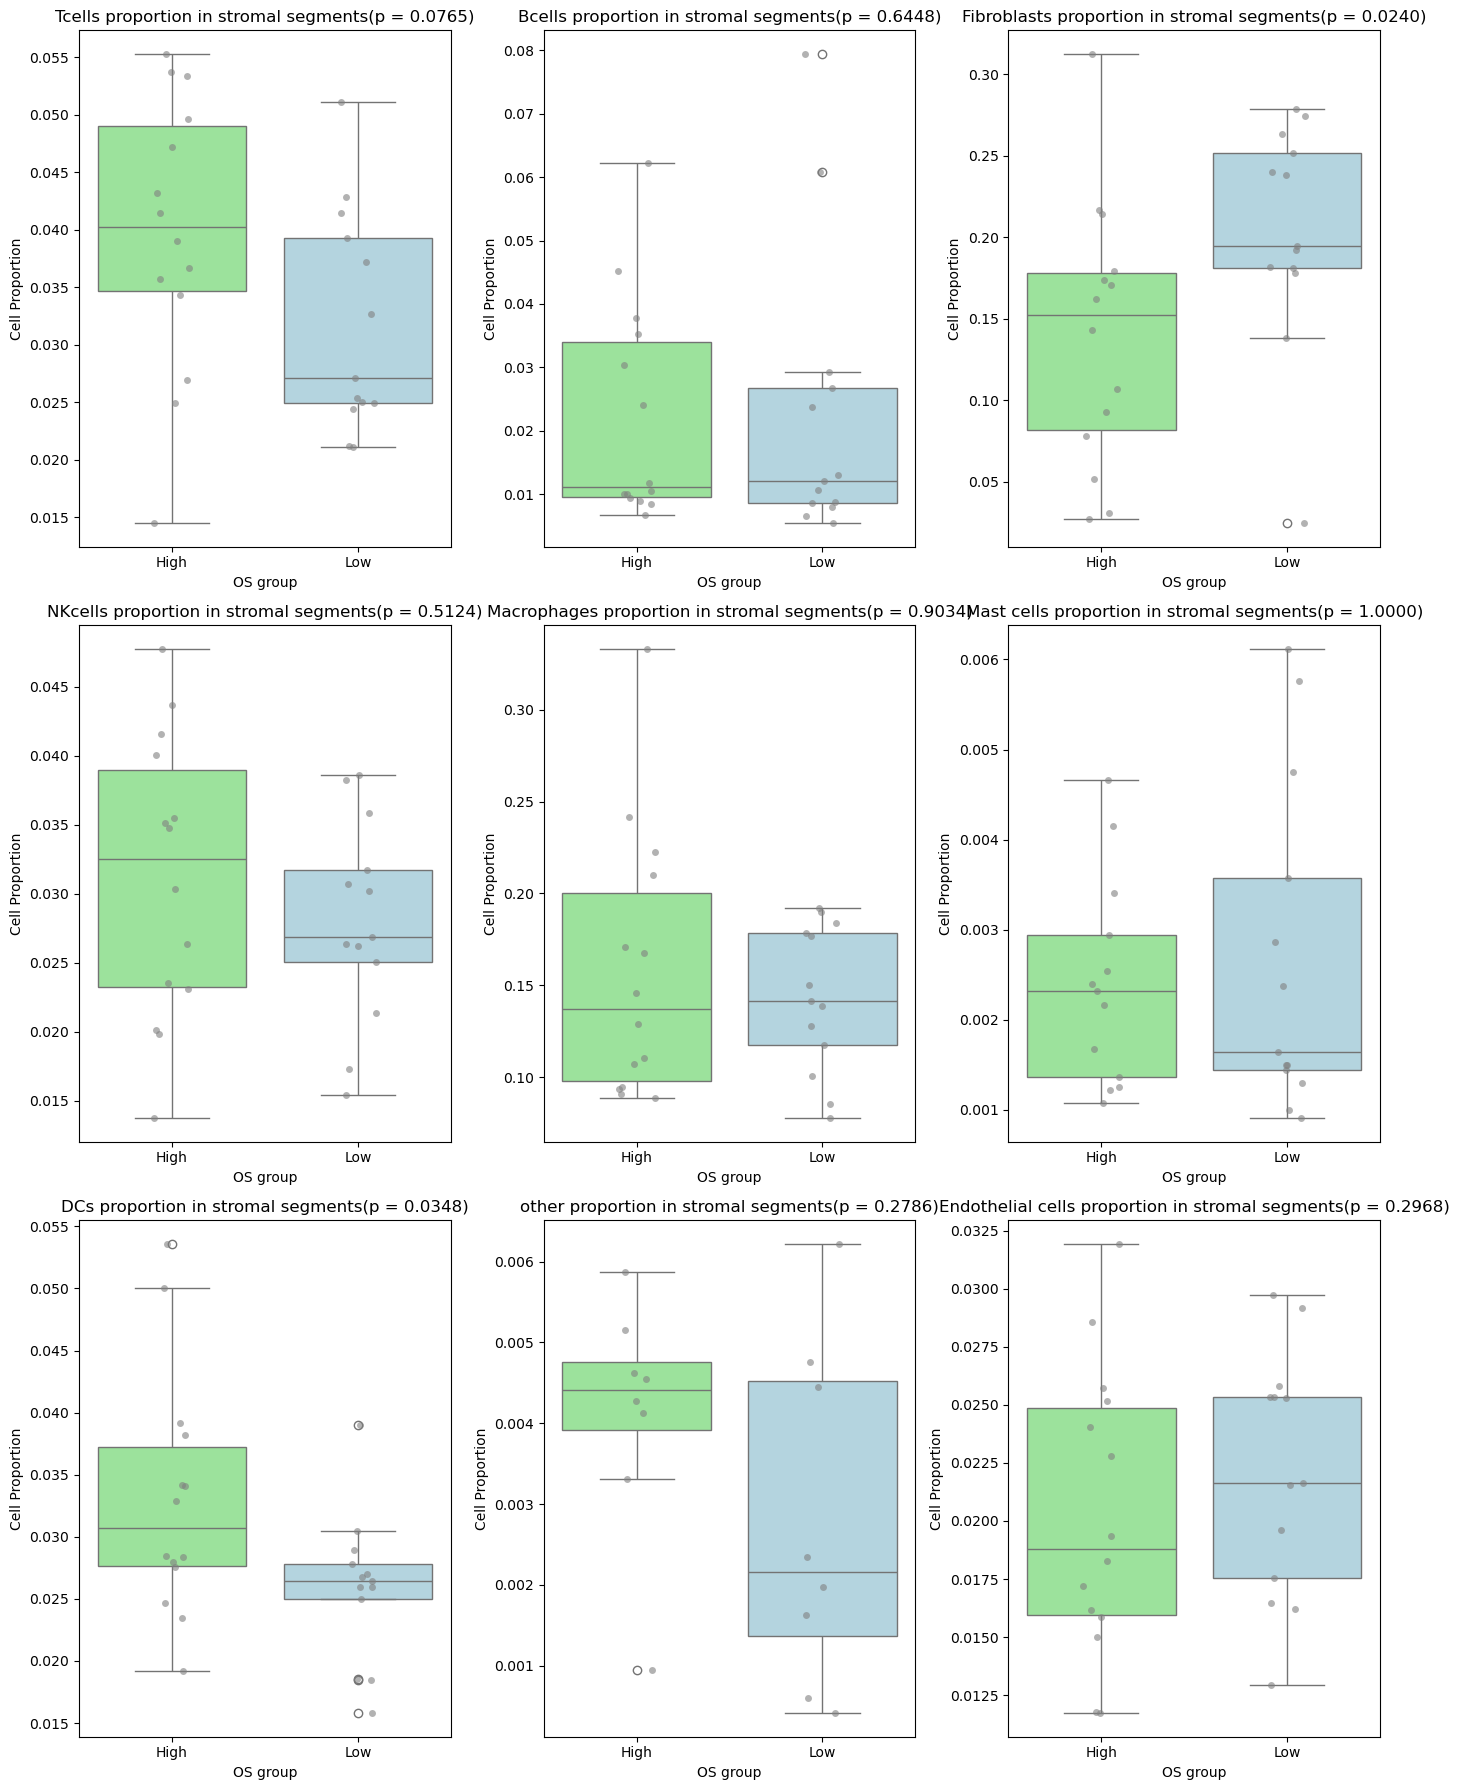

In [13]:
import math

num_plots = len(cell_types)
ncols = 3
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 6))
axes = axes.flatten()

for i, cell in enumerate(cell_types):
    combined = combined.reset_index(drop=True)
    ax = axes[i]

    # Extract data
    group_high = tsi[tsi["OS_HL_group"] == "High"][cell]
    group_low = tsi[tsi["OS_HL_group"] == "Low"][cell]
    group_high=group_high.dropna()
    group_low=group_low.dropna()

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_low, group_high, alternative='two-sided')

    # Plot
    sns.boxplot(x="OS_HL_group", y=cell, data=tsi, ax=ax, palette=["lightgreen", "lightblue"])
    sns.stripplot(x="OS_HL_group", y=cell, data=tsi, color='gray', alpha=0.6, jitter=True, ax=ax)

    # Label
    ax.set_title(f"{cell} proportion in stromal segments(p = {p_value:.4f})")
    ax.set_xlabel("OS group")
    ax.set_ylabel("Cell Proportion")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/310754821.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="OS_HL_group", y=cell, data=stroma_tsi_cell_abundance, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/310754821.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="OS_HL_group", y=cell, data=stroma_tsi_cell_abundance, ax=ax, palette=["lightgreen", "lightblue"])
/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_74075/310754821.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fals

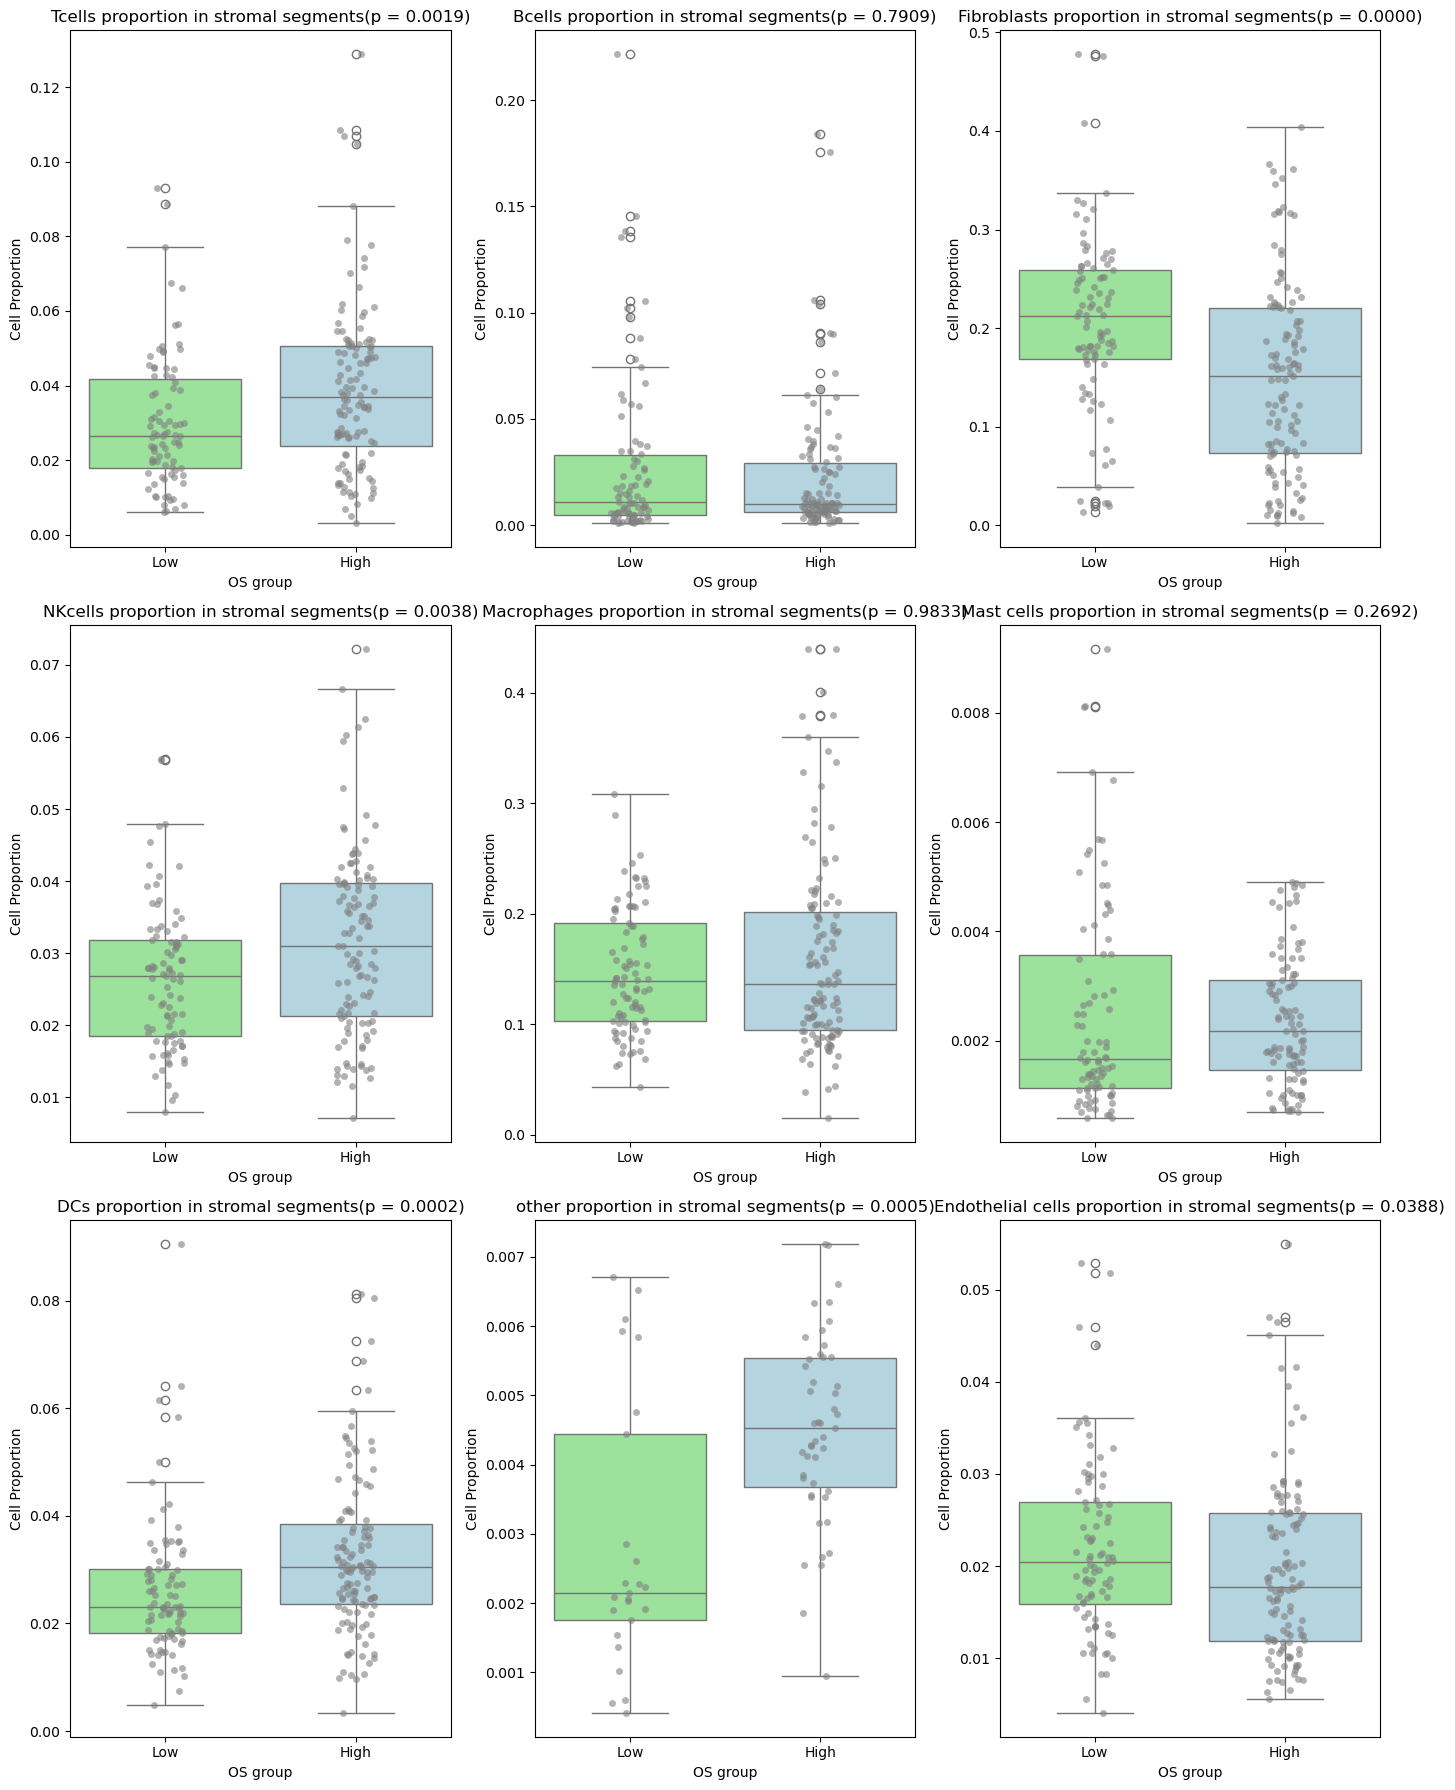

In [14]:
import math

num_plots = len(cell_types)
ncols = 3
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 6))
axes = axes.flatten()

for i, cell in enumerate(cell_types):
    combined = combined.reset_index(drop=True)
    ax = axes[i]

    # Extract data
    group_high = stroma_tsi_cell_abundance[stroma_tsi_cell_abundance["OS_HL_group"] == "High"][cell]
    group_low = stroma_tsi_cell_abundance[stroma_tsi_cell_abundance["OS_HL_group"] == "Low"][cell]
    group_high=group_high.dropna()
    group_low=group_low.dropna()

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_high, group_low, alternative='two-sided')

    # Plot
    sns.boxplot(x="OS_HL_group", y=cell, data=stroma_tsi_cell_abundance, ax=ax, palette=["lightgreen", "lightblue"])
    sns.stripplot(x="OS_HL_group", y=cell, data=stroma_tsi_cell_abundance, color='gray', alpha=0.6, jitter=True, ax=ax)

    # Label
    ax.set_title(f"{cell} proportion in stromal segments(p = {p_value:.4f})")
    ax.set_xlabel("OS group")
    ax.set_ylabel("Cell Proportion")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()